# YARP `yarpecule` tutorial

This notebook provides a self-contained overview of the `yarpecule` object in the **YARP 3.0** code base. The package is built around the `yarpecule`. Many of the yarp functions produce `yarpecules` take `yarpecules` as inputs, or are designed to analyze `yarpecules`.

The core attributes of the `yarpecule` class are the molecular graph (adjacency matrix) and associated bond–electron matrices. We'll focus on generating and analyzing these today. 

The tutorial is structured in three main sections.

1. An overview of the `yarpecule` object, including initialization from SMILES strings and XYZ files, and a survey of key attributes and methods.
2. A conceptual and practical overview of `find_lewis`
3. A description of `yarpecule` hashing.

## 0. Environment and imports

This notebook assumes that the `yarp-again` package has been installed in the current Python environment. The relevant instructions are 
1. to create a conda environment from the environment.yml file:  `conda env create -f environment.yml`
2. to perform a local install of yarp-again from the root directory: `pip install -e .`

In [1]:
# Import yarp (this is the preferred way to import yarp; we will generally also import the individual objects in this tutorial in case you haven't properly installed the package)
import yarp as yp

# Core numerical library used by YARP for arrays and linear algebra
import numpy as np

# The main object of interest in this tutorial
from yarp.yarpecule.yarpecule import yarpecule

# Hash utilities for atoms and molecules
from yarp.yarpecule.hashes import atom_hash, yarpecule_hash

# Lewis-structure helper functions
from yarp.yarpecule.lewis.bem_score import is_aromatic

# Basic utility: pretty-print small matrices with labels
def print_labeled_matrix(matrix, labels, fmt="{:4.0f}"):
    """Print a small 2D array with row/column labels.

    Parameters
    ----------
    matrix : array-like
        Square matrix to print (e.g., adjacency or bond-electron matrix).
    labels : sequence of str
        One label per row/column (typically element symbols).
    fmt : str, optional
        Format string used to print each numeric entry.
    """
    matrix = np.asarray(matrix)
    n = matrix.shape[0]

    # Header row with column labels
    header = ["    "] + [f"{i:>3}" for i in range(n)]
    print(" ".join(header))

    # Each row shows the index, label, and matrix entries
    for i in range(n):
        row_label = f"{i:>2} {labels[i]:>2}"
        entries = [fmt.format(matrix[i, j]) for j in range(n)]
        print(f"{row_label} " + " ".join(entries))

## 1. The `yarpecule` object

The `yarpecule` class is the central molecular container in YARP. It stores:

- The atomic identities and positions (`elements`, `geo`).
- The adjacency matrix (`adj_mat`) describing which atoms are bonded.
- The total charge (`q`) and per-atom masses (`masses`).
- One or more bond–electron matrices (`bond_mats`) that encode Lewis structures.
- A `lewis_struct` object that provides detailed Lewis-structure analysis, including formal charges and resonance information.
- Atom-level hashes and a molecule-level hash that can be used to identify unique atoms and unique molecular graphs.

A `yarpecule` can be constructed from several types of input:

- A SMILES string.
- A path to an XYZ file or MOL file.
- A tuple containing `(adj_mat, geometry, elements, charge)`.

### 1.1 `yarpecule` basics

The following few cells were generated in the belief that the best way to understand a library is to start doing things with it. 

In [2]:
ethene =yp.yarpecule("C=C")
ethene

We've done it! We can also load yarpecules from xyz files:

In [3]:
# Create a simple XYZ file for water.
# The file format is:
#   line 1: number of atoms
#   line 2: comment
#   subsequent lines: element x y z
water_xyz = """3
water
H  0.7570  0.5860  0.0000
H -0.7570  0.5860  0.0000
O  0.0000  0.0000  0.0000
"""

with open("water.xyz", "w") as f:
        f.write(water_xyz)

# Construct the yarpecule. The constructor detects the .xyz extension and uses the XYZ parser.
water = yarpecule("water.xyz")
water

Now that we can make yarpecules, let's look at some of their properties:

In [4]:
water = yarpecule("O")

# Inspect the most basic attributes.
print("Water elements:", water.elements)
print("Water charge q:", water.q)
print("Water geometry shape (N_atoms, 3):", water.geo.shape)
print(water.geo) #rdkit generated geometry
print()

Water elements: ['o', 'h', 'h']
Water charge q: 0
Water geometry shape (N_atoms, 3): (3, 3)
[[-0.00110703  0.3631372  -0.        ]
 [-0.8249853  -0.18194707 -0.        ]
 [ 0.82609233 -0.18119013  0.        ]]



Compare this with if we create the molecule from an xyz:

In [5]:
# use the xyz that we made above
water_2 = yarpecule("water.xyz")
# Inspect the most basic attributes.
print("Water elements:", water_2.elements)
print("Water charge q:", water_2.q)
print("Water geometry shape (N_atoms, 3):", water_2.geo.shape)
print(water_2.geo)
print()

Water elements: ['o', 'h', 'h']
Water charge q: 0
Water geometry shape (N_atoms, 3): (3, 3)
[[ 0.     0.     0.   ]
 [ 0.     0.757  0.586]
 [ 0.    -0.757  0.586]]



Notice anything odd?
...
Why did the element order change?
...
By default, `yarpecules` are canonicalized, meaning that their atom ordering is deterministically set by an algorithm. We'll discuss this later in the context of hashing, but for now it is important to note that you can turn off canonicalization with the `canon=False` option:



In [6]:
# use the xyz that we made above but preserve the original order via canon=False
water_3 = yarpecule("water.xyz", canon=False)
# Inspect the most basic attributes.
print("Water elements:", water_3.elements)
print("Water charge q:", water_3.q)
print("Water geometry shape (N_atoms, 3):", water_3.geo.shape)
print(water_3.geo)
print()

Water elements: ['h', 'h', 'o']
Water charge q: 0
Water geometry shape (N_atoms, 3): (3, 3)
[[ 0.757  0.586  0.   ]
 [-0.757  0.586  0.   ]
 [ 0.     0.     0.   ]]



You can also compare `yarpecules`

In [7]:
print(f"{water == ethene=}")

water == ethene=False


Makes sense...

In [8]:
print(f"{water == water_2=}")
print(f"{water == water_3=}")
print(f"{water_2 == water_3=}")

water == water_2=True
water == water_3=True
water_2 == water_3=True


Is this surprising in any way?

### 1.2 Adjacency and Bond-Electron Matrices
The main objects that motivated the creation of the `yarpecule` are the adjacency matrix and the bond electron matrix. The adjacency matrix provides the information on which atoms are in contact--either through a covalent, ionic, or dative bond. The bond-electron matrices provide the most likely Lewis Structures for the molecule. Each `yarpecule` has one adjacency matrix, but may have many bond-electron matrices.

In [9]:
CO3=yarpecule("O=C([O-])([O-])") # carbonate ion
print_labeled_matrix(CO3.adj_mat, CO3.elements, fmt="{:4.0f}")

       0   1   2   3
 0  c    0    1    1    1
 1  o    1    0    0    0
 2  o    1    0    0    0
 3  o    1    0    0    0


Carbonate has several resonance structures owing to the equivalent oxygens:

In [10]:
print(CO3.bond_mats)
print(CO3.bond_mat_scores)

[array([[0, 1, 2, 1],
       [1, 6, 0, 0],
       [2, 0, 4, 0],
       [1, 0, 0, 6]]), array([[0, 2, 1, 1],
       [2, 4, 0, 0],
       [1, 0, 6, 0],
       [1, 0, 0, 6]]), array([[0, 1, 1, 2],
       [1, 6, 0, 0],
       [1, 0, 6, 0],
       [2, 0, 0, 4]])]
[-0.6532926158219627, -0.6532926158219627, -0.6532926158219627]


benzene provides a larger example of the same

In [11]:
benzene = yarpecule("c1ccccc1")

# Inspect the most basic attributes.
print("Benzene elements:", benzene.elements)
print("Benzene charge q:", benzene.q)
print("Benzene geometry shape (N_atoms, 3):", benzene.geo.shape)
print(benzene.geo)
print()

Benzene elements: ['c', 'c', 'c', 'c', 'c', 'c', 'h', 'h', 'h', 'h', 'h', 'h']
Benzene charge q: 0
Benzene geometry shape (N_atoms, 3): (12, 3)
[[-0.29287484 -1.3345605  -0.00870462]
 [-1.33539095 -0.4187878   0.01502167]
 [-1.0149724   0.93857087  0.02355363]
 [ 0.31777768  1.35946575  0.00858968]
 [ 1.32584957  0.41543598 -0.01491782]
 [ 1.02311824 -0.9342707  -0.02362794]
 [-0.50845117 -2.39834545 -0.01589662]
 [-2.36492881 -0.75034826  0.02651579]
 [-1.82756796  1.65735088  0.04209727]
 [ 0.52036427  2.43329081  0.01606513]
 [ 2.36321539  0.7228598  -0.02676189]
 [ 1.793861   -1.69066138 -0.04193429]]



In [12]:
# Examine the adjacency matrix for benzene.
print("Benzene adjacency matrix:")
print_labeled_matrix(benzene.adj_mat, benzene.elements, fmt="{:4.0f}")

Benzene adjacency matrix:
       0   1   2   3   4   5   6   7   8   9  10  11
 0  c    0    1    0    0    0    1    1    0    0    0    0    0
 1  c    1    0    1    0    0    0    0    1    0    0    0    0
 2  c    0    1    0    1    0    0    0    0    1    0    0    0
 3  c    0    0    1    0    1    0    0    0    0    1    0    0
 4  c    0    0    0    1    0    1    0    0    0    0    1    0
 5  c    1    0    0    0    1    0    0    0    0    0    0    1
 6  h    1    0    0    0    0    0    0    0    0    0    0    0
 7  h    0    1    0    0    0    0    0    0    0    0    0    0
 8  h    0    0    1    0    0    0    0    0    0    0    0    0
 9  h    0    0    0    1    0    0    0    0    0    0    0    0
10  h    0    0    0    0    1    0    0    0    0    0    0    0
11  h    0    0    0    0    0    1    0    0    0    0    0    0


### 1.3 Survey of key `yarpecule` attributes and methods

A `yarpecule` instance exposes a collection of properties that provide a high-level view of the molecular graph
and its Lewis structures. The following attributes are particularly important:

- `geo` (property): an `N_atom × 3` NumPy array of Cartesian coordinates in ångström.
- `elements` (property): a list of lower-case element labels ordered consistently with the rows and columns of the matrices.
- `q` (property): the total integer charge on the molecule.
- `adj_mat` (property): the adjacency matrix of the covalent graph; entries are 1 if atoms are bonded and 0 otherwise.
- `bond_mats` (property): a list of bond–electron matrices corresponding to Lewis structures. Off-diagonal entries represent bond orders; diagonal entries count non-bonding electrons.
- `bond_mat_scores` (property): one score per bond–electron matrix, produced by the Lewis-structure scoring function.
- `lewis` (property): the underlying `lewis_struct` object that holds detailed Lewis information and helper methods.
- `bo_dict` (property): a dictionary-of-dictionaries summarizing the set of bond orders observed between each pair of atoms across all Lewis structures.
- `fc` (property): an array of formal charges for the highest-scoring Lewis structure.
- `rings` (property): a list of rings (each represented as a list of atom indices) used in aromaticity analysis.
- `atom_hashes` (property): an array of per-atom hash values encoding graph environment information.
- `hash` (property): the molecule-level `yarpecule` hash value.
- `canon_smi` (property): a canonical SMILES string generated via RDKit once `get_smiles` has been called.
- `map_smi` (property): an atom-mapped SMILES string, again generated via RDKit.

A small subset of methods that appear frequently in workflows is:

- `get_smiles()`: generate canonical and atom-mapped SMILES strings for the current `yarpecule`.
- `get_inchi()`: compute and store an InChI identifier using RDKit.
- `join(other)` (sometimes called “union” in comments): form a new `yarpecule` that is the disjoint union of this molecule with one or more others.
- `separate()`: split a disconnected `yarpecule` into a list of separate `yarpecule` objects.
- `draw_bmats()`: create a PDF or inline image showing the bond–electron matrices with annotated scores.

The next cell demonstrates several of these attributes and methods on benzene.

In [13]:
# Reuse the benzene yarpecule from above
benzene = yarpecule("c1ccccc1")

# Trigger generation of SMILES variants and InChI.
# These routines use RDKit internally and leave the molecular graph unchanged.
benzene.get_smiles()
benzene.get_inchi()

print("Elements:", benzene.elements)
print("Total charge q:", benzene.q)
print("Canonical SMILES:", benzene.canon_smi)
print("Atom-mapped SMILES:", benzene.map_smi)
print("InChI key:", benzene.inchi)
print()

# Show ring information and identify the rings in terms of atom indices.
print("Rings (as lists of atom indices):", benzene.rings)
print()

Elements: ['c', 'c', 'c', 'c', 'c', 'c', 'h', 'h', 'h', 'h', 'h', 'h']
Total charge q: 0
Canonical SMILES: c1ccccc1
Atom-mapped SMILES: [c:0]1([H:6])[c:1]([H:7])[c:2]([H:8])[c:3]([H:9])[c:4]([H:10])[c:5]1[H:11]
InChI key: UHOVQNZJYSORNB

Rings (as lists of atom indices): [[0, 1, 2, 3, 4, 5]]



In [14]:
# List the available bond–electron matrices and their scores.
print(f"Number of bond-electron matrices: {len(benzene.bond_mats)}")
for idx, (bmat, score) in enumerate(zip(benzene.bond_mats, benzene.bond_mat_scores)):
    print(f"Structure {idx}  score = {score:.3f}")
    print_labeled_matrix(bmat, benzene.elements, fmt="{:4.0f}")
    print()

# Examine the formal charges and bond-order dictionary for the best-scoring structure.
print("Formal charges for best structure:", benzene.fc)
print()

Number of bond-electron matrices: 2
Structure 0  score = -4.040
       0   1   2   3   4   5   6   7   8   9  10  11
 0  c    0    2    0    0    0    1    1    0    0    0    0    0
 1  c    2    0    1    0    0    0    0    1    0    0    0    0
 2  c    0    1    0    2    0    0    0    0    1    0    0    0
 3  c    0    0    2    0    1    0    0    0    0    1    0    0
 4  c    0    0    0    1    0    2    0    0    0    0    1    0
 5  c    1    0    0    0    2    0    0    0    0    0    0    1
 6  h    1    0    0    0    0    0    0    0    0    0    0    0
 7  h    0    1    0    0    0    0    0    0    0    0    0    0
 8  h    0    0    1    0    0    0    0    0    0    0    0    0
 9  h    0    0    0    1    0    0    0    0    0    0    0    0
10  h    0    0    0    0    1    0    0    0    0    0    0    0
11  h    0    0    0    0    0    1    0    0    0    0    0    0

Structure 1  score = -4.040
       0   1   2   3   4   5   6   7   8   9  10  11
 0  c    

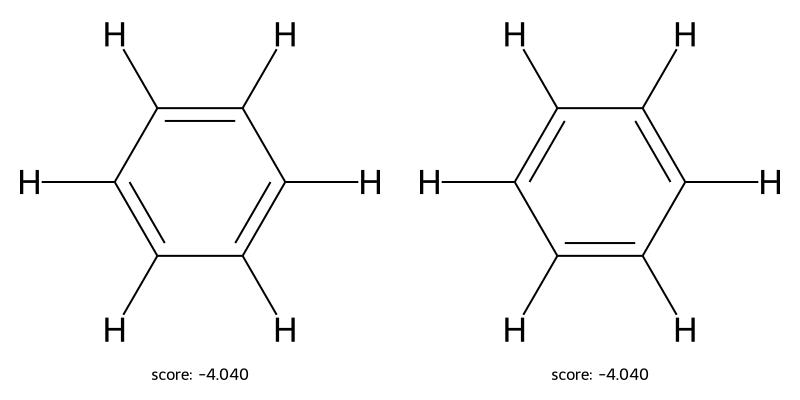

In [15]:
# Visualize bond-electon matrices and their scores
benzene.draw_bmats(show_inline=True)

# For use in a python script, this can be written to a PDF
# benzene.draw_bmats('benzene.pdf')

We can also join and disconnect `yarpecules`:

Before join:
  component 0: [O:0]([H:1])[H:2]
  component 1: [c:0]1([H:6])[c:1]([H:7])[c:2]([H:8])[c:3]([H:9])[c:4]([H:10])[c:5]1[H:11]
After join: [O:0]([H:1])[H:2].[c:3]1([H:9])[c:4]([H:10])[c:5]([H:11])[c:6]([H:12])[c:7]([H:13])[c:8]1[H:14]
  component 1, atom index 0: atom map 0 -> 3
  component 1, atom index 1: atom map 1 -> 4
  component 1, atom index 2: atom map 2 -> 5
  component 1, atom index 3: atom map 3 -> 6
  component 1, atom index 4: atom map 4 -> 7
  component 1, atom index 5: atom map 5 -> 8
  component 1, atom index 6: atom map 6 -> 9
  component 1, atom index 7: atom map 7 -> 10
  component 1, atom index 8: atom map 8 -> 11
  component 1, atom index 9: atom map 9 -> 12
  component 1, atom index 10: atom map 10 -> 13
  component 1, atom index 11: atom map 11 -> 14
['c', 'c', 'c', 'c', 'c', 'c', 'h', 'h', 'h', 'h', 'h', 'h', 'o', 'h', 'h']
['o', 'h', 'h']
['c', 'c', 'c', 'c', 'c', 'c', 'h', 'h', 'h', 'h', 'h', 'h']


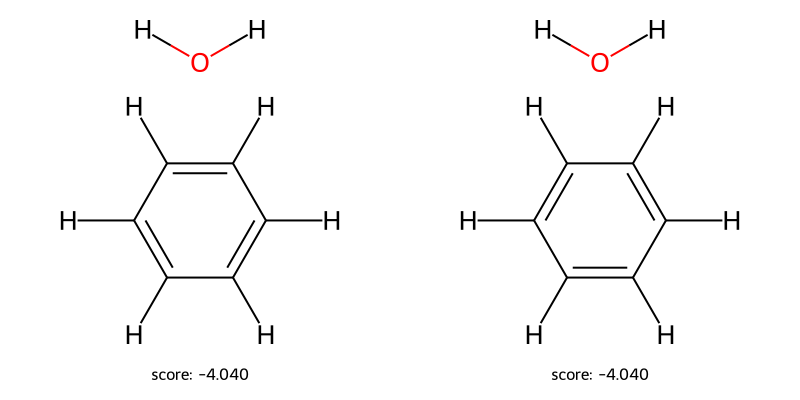

2
['c', 'c', 'c', 'c', 'c', 'c', 'h', 'h', 'h', 'h', 'h', 'h']


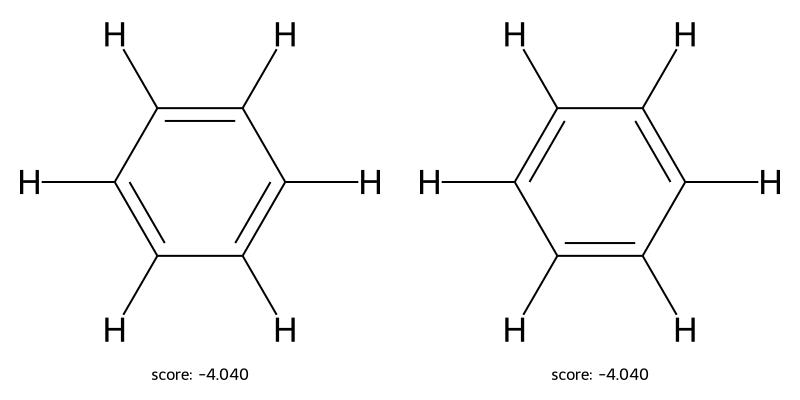

['o', 'h', 'h']


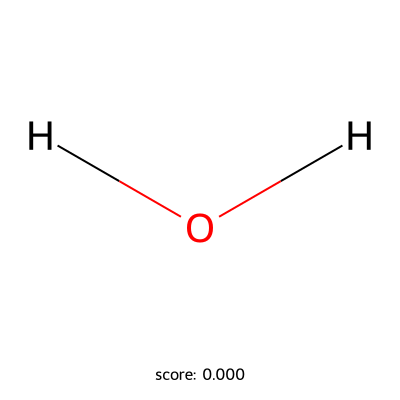

In [16]:
# Add a benzene yarpecule on to a
combined = water.join(benzene)
print(combined.elements)
print(water.elements)
print(benzene.elements)
combined.draw_bmats(show_inline=True)

# Separate a single yarpecule into a list of one or more yarpecules
separated = combined.separate()
print(len(separated))
print(separated[0].elements) # benzene
separated[0].draw_bmats(show_inline=True)
print(separated[1].elements) # water
separated[1].draw_bmats(show_inline=True)

## 2. Lewis-structure search (`find_lewis`)

The Lewis-structure machinery in YARP is implemented in the `lewis_struct` class and the helper functions
in `yarp.yarpecule.lewis.be_mat`. When a `yarpecule` is constructed, the private method `_gen_lewis_struct`
is called, which creates a `lewis_struct` instance, enumerates candidate bond–electron matrices, and scores
them to identify chemically reasonable Lewis structures.

Although the original code (classy YARP) refers to a function called `find_lewis`, the core algorithm is implemented as
the `_gen_bond_el_mat` method of `lewis_struct`. The algorithm takes as input the adjacency matrix,
element types, and overall charge, and returns a small collection of bond–electron matrices together with
associated scores and derived quantities.

### 2.1 Conceptual overview of the algorithm

At a high level, the Lewis-structure search proceeds as follows:

1. **Initialization of electron bookkeeping.** The algorithm computes, for each atom, the number of valence electrons, the preferred electron count for an octet, and whether the atom can expand its octet. This uses element-specific data such as `el_valence`, `el_n_deficient`, and `el_n_expand_octet`.
2. **Ring detection and aromaticity preparation.** The ring system for the adjacency graph is identified using `return_rings`. For each small ring, YARP later evaluates whether that ring is aromatic, non-aromatic, or antiaromatic using an explicit count of π electrons.
3. **Construction of initial bond–electron matrices.** A starting bond–electron matrix is built that satisfies the adjacency constraints with minimal bond orders and distributes the remaining electrons as unshared (lone-pair or radical) electrons on the diagonal.
4. **Exploration of alternative matrices.** The `gen_all_lstructs` routine applies a set of local transformations that move electrons between bonds and atomic sites while respecting valence rules. These operations include forming multiple bonds, transferring electron pairs, and (when permitted) expanding octets, and are applied subject to graph-distance constraints when `local_opt=True`.
5. **Scoring candidate structures.** Each candidate bond–electron matrix is scored with the `bmat_score` objective function. The score penalizes electron deficiencies, expanded octets and formal charges, and includes an aromaticity term that rewards aromatic rings and penalizes antiaromatic rings. Radical centers are also penalized, with the penalty modulated by the local chemical environment.
6. **Selection of relevant Lewis structures.** The algorithm keeps only those bond–electron matrices whose scores are within a threshold `mats_thresh` of the best score, up to a maximum of `mats_max` structures. These matrices represent a small set of chemically plausible resonance structures.
7. **Post-processing and summaries.** Once the set of matrices has been selected, YARP computes formal charges, electron-donor and electron-acceptor counts, atom neighbour sets, and the bond-order dictionary (`bo_dict`) summarizing the possible bond orders across all structures.

The result is a compact representation of all “reasonable” Lewis structures for a given molecular graph, together
with diagnostics that are useful for mechanistic and reactivity analyses.

### 2.2 Inputs and outputs of the Lewis-structure search

The Lewis-structure search is invoked implicitly when a `yarpecule` is constructed. Conceptually, the main
inputs to the algorithm are:

- `elements`: a list of element labels indexed consistently with the adjacency matrix.
- `adj_mat`: the integer adjacency matrix describing which atoms are bonded.
- `q`: the total charge on the molecule.
- `rings`: an optional list of rings; if not supplied, they are computed.
- Hyperparameters such as `mats_max`, `mats_thresh`, and the weights `w_def`, `w_exp`, `w_formal`, `w_aro`, and `w_rad` in the scoring function.

The main outputs, exposed through the `lewis_struct` object and mirrored as properties on the `yarpecule`, are:

- `bond_mats`: a list of bond–electron matrices.
- `scores`: a list of scores, one per bond–electron matrix.
- `e_acceptors`: per-atom counts of how many electrons each atom can accept without violating octet rules.
- `e_donors`: per-atom counts of how many electrons each atom can donate from non-bonding orbitals.
- `formal_charge`: formal charges for the highest-scoring bond–electron matrix.
- `atom_neighbors`: for each atom, the set containing that atom and its neighbours (useful for local reactivity analysis).
- `bo_dict`: the dictionary-of-dictionaries of possible bond orders.

The next cell illustrates the shape of these outputs for a simple organic anion:
acetate.

Acetate elements: ['c', 'c', 'o', 'o', 'h', 'h', 'h']
Acetate total charge q: -1

Number of Lewis structures (bond-electron matrices): 2
Structure 0  score = -0.327
       0   1   2   3   4   5   6
 0  c    0    1    0    0    1    1    1
 1  c    1    0    2    1    0    0    0
 2  o    0    2    4    0    0    0    0
 3  o    0    1    0    6    0    0    0
 4  h    1    0    0    0    0    0    0
 5  h    1    0    0    0    0    0    0
 6  h    1    0    0    0    0    0    0

Structure 1  score = -0.327
       0   1   2   3   4   5   6
 0  c    0    1    0    0    1    1    1
 1  c    1    0    1    2    0    0    0
 2  o    0    1    6    0    0    0    0
 3  o    0    2    0    4    0    0    0
 4  h    1    0    0    0    0    0    0
 5  h    1    0    0    0    0    0    0
 6  h    1    0    0    0    0    0    0

Formal charges (best structure): [ 0  0  0 -1  0  0  0]
Electron acceptor counts (best structure): [0 2 2 0 0 0 0]
Electron donor counts (best structure): [0 2 6 6 0

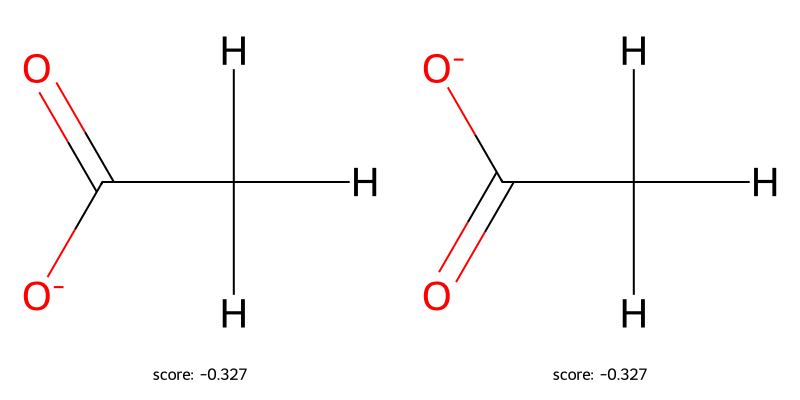

In [17]:
# Acetate anion: a simple example with resonance
acetate_smi = "CC(=O)[O-]"
acetate = yarpecule(acetate_smi, mode="yarp")

# For convenience, reference the underlying lewis_struct object
ls = acetate.lewis

print("Acetate elements:", acetate.elements)
print("Acetate total charge q:", acetate.q)
print()

print(f"Number of Lewis structures (bond-electron matrices): {len(acetate.bond_mats)}")
for idx, (bmat, score) in enumerate(zip(acetate.bond_mats, acetate.bond_mat_scores)):
    print(f"Structure {idx}  score = {score:.3f}")
    print_labeled_matrix(bmat, acetate.elements, fmt="{:4.0f}")
    print()

print("Formal charges (best structure):", acetate.fc)
print("Electron acceptor counts (best structure):", acetate.n_e_accept)
print("Electron donor counts (best structure):", acetate.n_e_donate)

acetate.draw_bmats(show_inline=True)

### 2.3 Resonance structures and bond-order sets

When multiple resonance structures are available, the Lewis-structure search will typically return several
bond–electron matrices with very similar scores. The `bo_dict` helper summarizes the set of bond orders observed
across all of these matrices.

For acetate, the two C–O bonds in the carboxylate group should have bond-order sets that include both single
and double bonds, reflecting the usual resonance description in which the negative charge and π bond are
delocalized over the two oxygens.

The next cell inspects the bond-order dictionary for the carboxylate fragment of acetate.

In [18]:
# Use the precomputed bond-order dictionary on the acetate yarpecule
bo = acetate.bo_dict

print("Bond-order sets for C-O bonds in acetate:")

# Identify indices of carbon and oxygen atoms.
c_indices = [i for i, el in enumerate(acetate.elements) if el == "c"]
o_indices = [i for i, el in enumerate(acetate.elements) if el == "o"]

for i in c_indices:
    for j in o_indices:
        if bo[i][j] is not None:
            print(f"  Bond ({i}, {j}) orders:", sorted(bo[i][j]))

Bond-order sets for C-O bonds in acetate:
  Bond (1, 2) orders: [1, 2]
  Bond (1, 3) orders: [1, 2]


### 2.4 Treatment of radicals

Radical centers are represented within a bond–electron matrix by an odd number of non-bonding electrons
on the diagonal element corresponding to the radical atom. The scoring function `bmat_score` includes a
radical penalty term that disfavors radicals in general, but allows them when required by the adjacency
and electron count.

The next example uses the benzene radical cation, which shares the same adjacency as benzene but has one
fewer electron. The atom-level hashes will be identical (because they depend only on the graph connectivity
and masses), but the bond–electron matrices and the overall `yarpecule` hash will differ from neutral
benzene.

Number of Lewis structures (neutral): 2


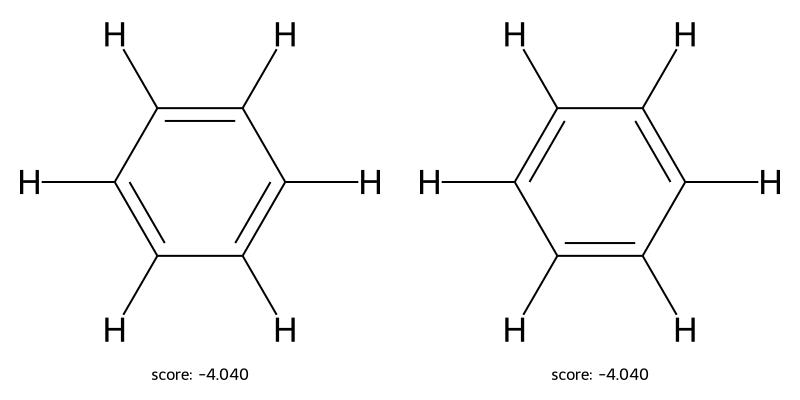

Number of Lewis structures (radical cation): 10


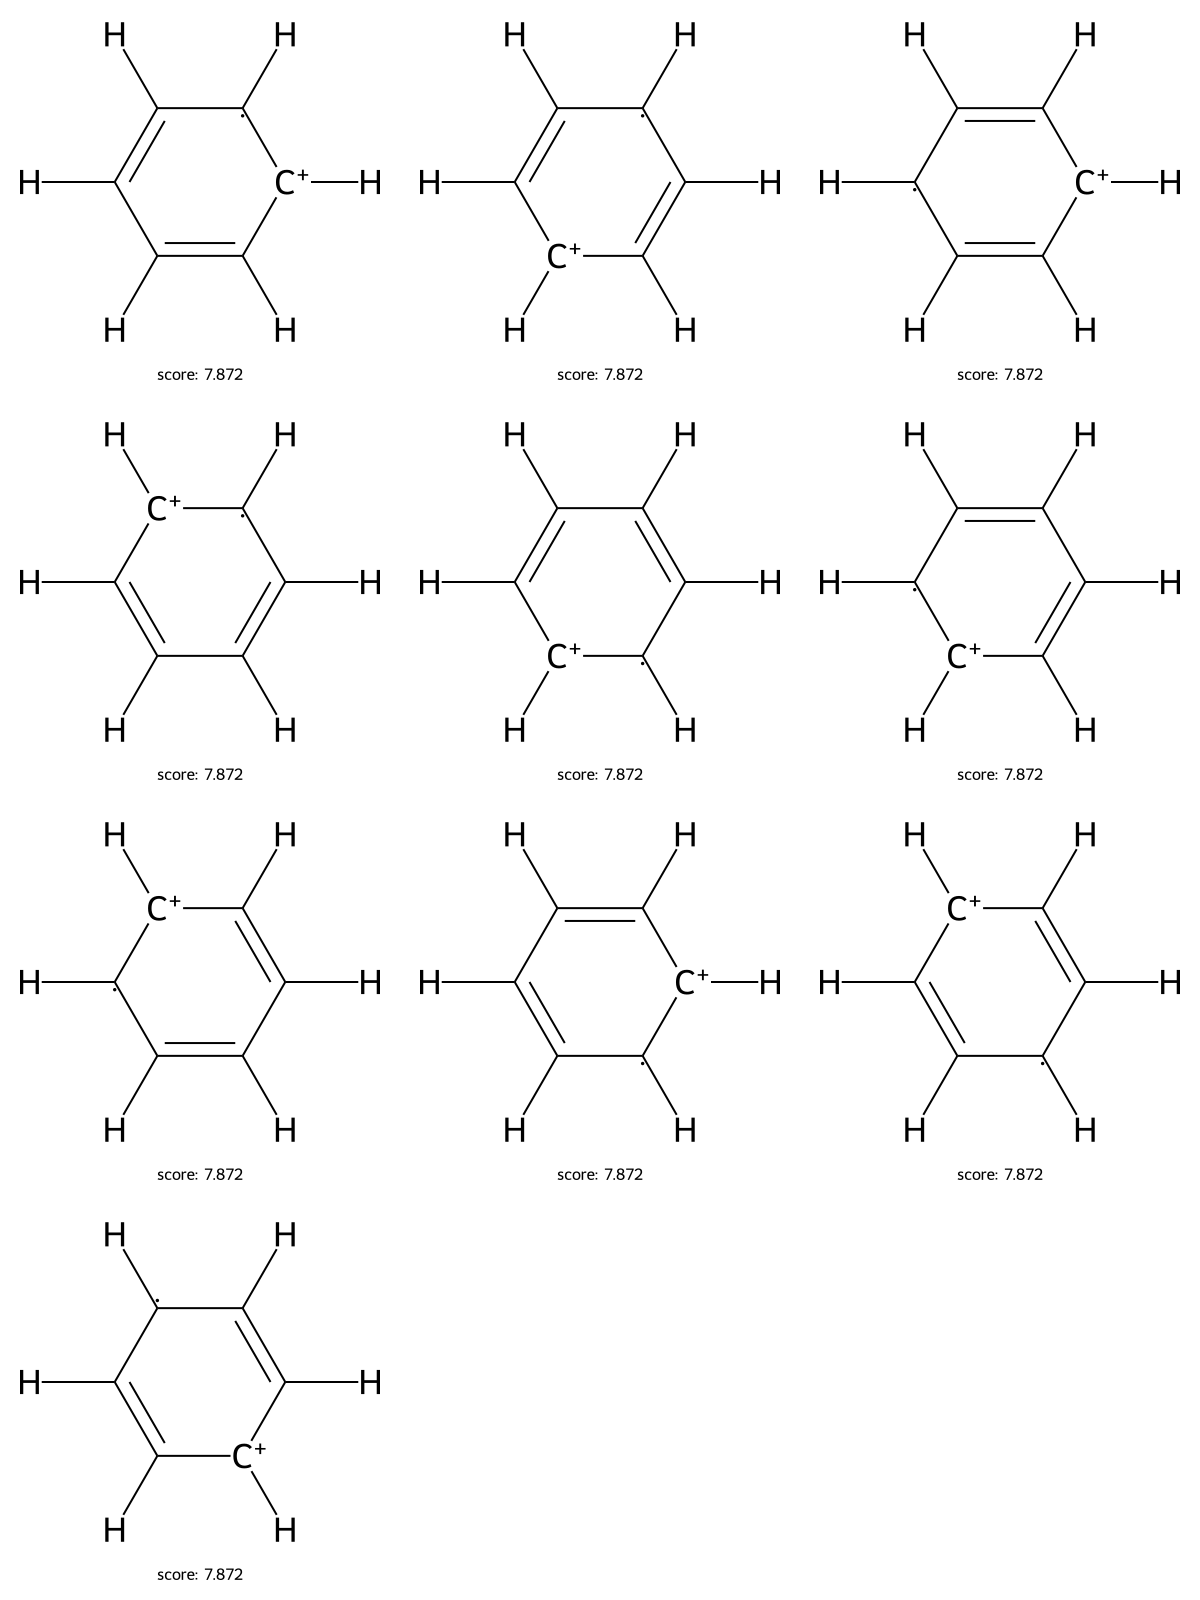

In [19]:
# Neutral benzene and benzene radical cation
benzene_neutral = yarpecule("c1ccccc1")
benzene_rad_cat = yarpecule("[CH]1C=CC=C[CH+]1")

print("Number of Lewis structures (neutral):", len(benzene_neutral.bond_mats))
benzene_neutral.draw_bmats(show_inline=True)
print("Number of Lewis structures (radical cation):", len(benzene_rad_cat.bond_mats))
benzene_rad_cat.draw_bmats(show_inline=True)
print()


In [20]:
# Show the diagonal of the best bond–electron matrix (non-bonding electrons) for both species
print("Diagonal entries (non-bonding electrons) for neutral benzene:")
print(np.diag(benzene_neutral.bond_mats[0]))
print()

print("Diagonal entries (non-bonding electrons) for benzene radical cation:")
print(np.diag(benzene_rad_cat.bond_mats[0]))
print()

# Compare atom-level hashes and yarpecule-level hashes
print("Atom hashes identical?", np.array_equal(benzene_neutral.atom_hashes, benzene_rad_cat.atom_hashes))
print("Neutral benzene hash:", benzene_neutral.hash)
print("Radical cation hash:", benzene_rad_cat.hash)

Diagonal entries (non-bonding electrons) for neutral benzene:
[0 0 0 0 0 0 0 0 0 0 0 0]

Diagonal entries (non-bonding electrons) for benzene radical cation:
[0 0 0 0 0 1 0 0 0 0 0 0]

Atom hashes identical? True
Neutral benzene hash: 3997399.8538324
Radical cation hash: 19078095.3893439


### 2.5 Azulene: aromatic and antiaromatic contributions

Azulene is a fused bicyclic hydrocarbon with a five-membered ring fused to a seven-membered ring. It has
ten π electrons overall and is experimentally aromatic, but the distribution of π electrons between the
two rings involves both aromatic and antiaromatic contributions when individual rings are considered.

YARP detects aromatic and antiaromatic rings using the `is_aromatic` helper. For a given bond–electron
matrix and a ring (a list of atom indices), `is_aromatic` returns:

- `1` for an aromatic ring.
- `0` for a non-aromatic ring.
- `-1` for an antiaromatic ring.

The aromaticity contribution enters the Lewis-structure score via a ring-weighted sum over all rings in the
molecule. The following cell constructs an azulene `yarpecule`, examines its rings, and evaluates
their aromaticity for the best-scoring bond–electron matrix.

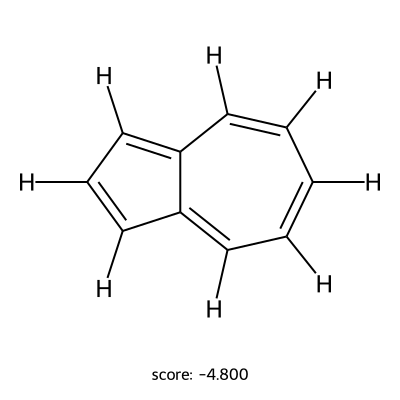

Azulene elements: ['c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'h', 'h', 'h', 'h', 'h', 'h', 'h', 'h']
Rings in azulene (indices): [[0, 1, 3, 6, 2], [0, 1, 5, 8, 9, 7, 4]]

Ring 0: atoms [0, 1, 3, 6, 2] -> non-aromatic
Ring 1: atoms [0, 1, 5, 8, 9, 7, 4] -> non-aromatic


In [21]:
# Azulene SMILES (10-π-electron bicyclic aromatic system)
azulene_smi = "c1ccc2cccc2cc1"
azulene = yarpecule(azulene_smi, mode="rdkit")
azulene.draw_bmats(show_inline=True)

print("Azulene elements:", azulene.elements)
print("Rings in azulene (indices):", azulene.rings)
print()

# Take the best-scoring bond–electron matrix
best_bmat = azulene.bond_mats[0]

# Evaluate aromaticity for each ring
for idx, ring in enumerate(azulene.rings):
    aro_flag = is_aromatic(best_bmat, ring)
    label = {1: "aromatic", 0: "non-aromatic", -1: "antiaromatic"}[aro_flag]
    print(f"Ring {idx}: atoms {ring} -> {label}")



## 3. Hashing: atom-level and `yarpecule`-level hashes

YARP uses hash functions at two levels to distinguish atoms and entire molecules in a way that is robust
to atom ordering but sensitive to changes in connectivity, charge state, and (when masses are adjusted)
isotopic substitution.

1. **Atom hashes.** The `atom_hash` function assigns a floating-point value to each atom that depends on
   its graph environment and the per-atom masses. Atoms that are symmetry-equivalent in the molecular graph
   have identical hash values, whereas atoms in distinct environments usually have different hashes.
2. **Bond–electron matrix hashes.** The `bmat_hash` function compresses a single bond–electron matrix into
   a scalar value. This is used internally to detect duplicate Lewis structures efficiently.
3. **`yarpecule` hash.** The `yarpecule_hash` function combines the atom hashes with the sum of all
   bond–electron matrices to produce a single scalar hash for the entire molecule. This value is exposed
   as the `hash` property of a `yarpecule` instance.

The following subsections illustrate these ideas.

### 3.1 Atom hashes and symmetry

The atom hash for atom index `i` is computed by `atom_hash(i, adj_mat, masses, alpha, beta, gens)`.
Conceptually, the hash consists of two contributions:

- A local term proportional to the degree of the atom in the adjacency graph.
- A recursive term obtained by walking the graph outward to a depth of `gens` without backtracking. At each
  step `s` of this walk, the masses of the newly visited atoms are added with a geometric damping factor
  proportional to `beta × 0.1^s`.

The result is that atoms with identical local environments and symmetric surroundings receive identical
hash values, whereas atoms in distinct environments receive different values. Because only the adjacency
matrix and the per-atom masses enter into the calculation, atom hashes are insensitive to the total charge
or to the particular Lewis structure chosen for a molecule.

The next cell illustrates atom hashes for water (where the two hydrogen atoms are symmetry-equivalent) and
benzene (where all six carbon atoms are equivalent in the canonical labelling).

In [22]:
# Reuse the water and benzene yarpecules constructed earlier
water = yarpecule("O")  # RDKit will add hydrogens implicitly
benzene = yarpecule("c1ccccc1")

print("Water atom hashes:")
for idx, (el, h) in enumerate(zip(water.elements, water.atom_hashes)):
    print(f"  Atom {idx:2d} ({el}): {h:.6f}")
print()

print("Benzene atom hashes:")
for idx, (el, h) in enumerate(zip(benzene.elements, benzene.atom_hashes)):
    print(f"  Atom {idx:2d} ({el}): {h:.6f}")
print()

# Group atoms by hash value using a tolerance to account for floating-point rounding
def group_by_hash(elements, hashes, tol=1e-6):
    """Group atom indices by approximate equality of hash values."""
    groups = []
    used = set()
    for i, h in enumerate(hashes):
        if i in used:
            continue
        group = [i]
        used.add(i)
        for j in range(i + 1, len(hashes)):
            if j in used:
                continue
            if abs(hashes[j] - h) < tol:
                group.append(j)
                used.add(j)
        groups.append((h, group))
    return groups

print("Symmetry-equivalent atoms grouped by hash (water):")
for h, group in group_by_hash(water.elements, water.atom_hashes):
    labels = [water.elements[i] for i in group]
    print(f"  Hash ~ {h:.6f} -> atoms {group} ({labels})")
print()

print("Symmetry-equivalent atoms grouped by hash (benzene):")
for h, group in group_by_hash(benzene.elements, benzene.atom_hashes):
    labels = [benzene.elements[i] for i in group]
    print(f"  Hash ~ {h:.6f} -> atoms {group} ({labels})")

Water atom hashes:
  Atom  0 (o): 201.620099
  Atom  1 (h): 100.261796
  Atom  2 (h): 100.261796

Benzene atom hashes:
  Atom  0 (c): 301.480328
  Atom  1 (c): 301.480328
  Atom  2 (c): 301.480328
  Atom  3 (c): 301.480328
  Atom  4 (c): 301.480328
  Atom  5 (c): 301.480328
  Atom  6 (h): 100.247819
  Atom  7 (h): 100.247819
  Atom  8 (h): 100.247819
  Atom  9 (h): 100.247819
  Atom 10 (h): 100.247819
  Atom 11 (h): 100.247819

Symmetry-equivalent atoms grouped by hash (water):
  Hash ~ 201.620099 -> atoms [0] (['o'])
  Hash ~ 100.261796 -> atoms [1, 2] (['h', 'h'])

Symmetry-equivalent atoms grouped by hash (benzene):
  Hash ~ 301.480328 -> atoms [0, 1, 2, 3, 4, 5] (['c', 'c', 'c', 'c', 'c', 'c'])
  Hash ~ 100.247819 -> atoms [6, 7, 8, 9, 10, 11] (['h', 'h', 'h', 'h', 'h', 'h'])


### 3.2 The `yarpecule` hash: definition and invariance properties

The molecule-level hash exposed as the `hash` property of a `yarpecule` is computed by the `yarpecule_hash`
helper. In the current implementation:

1. All bond–electron matrices for the molecule are summed to form an aggregate matrix `B_sum`.
2. The outer product of the atom-hash vector `h` with itself is formed, yielding a matrix `H_ij = h_i h_j`.
3. The elementwise product `B_sum ⊙ H` is computed.
4. The entries of this product are summed and rounded to a fixed number of decimal places.

Symbolically, if `B_sum` is the sum over all bond–electron matrices and `h_i` are the atom hashes, the
hash value is
\[
H(\text{yarpecule}) = \operatorname{round}\left( \sum_{i,j} B_{\text{sum},ij} h_i h_j,\; 7 \right).
\]

This construction has several important consequences:

- Permuting the atom indices does not change the hash, because both `B_sum` and the set of atom hashes
  transform consistently under relabelling.
- Changing the formal charge distribution, and hence the bond–electron matrices, changes the hash even if the
  adjacency matrix remains the same.
- Changing the per-atom masses changes the atom hashes and therefore the overall `yarpecule` hash. This
  provides a path to treating isotopomers as distinct molecules at the hashing level.

The next cells illustrate these properties.

#### 3.2.1 Same molecule, different SMILES / atom ordering

SMILES is not unique: many distinct SMILES strings can represent the same molecular graph. For example,
`CCO` and `OCC` both represent ethanol. When `canon=False` is requested in the `yarpecule` constructor,
the internal atom indices follow the SMILES parsing order, so these two inputs correspond to different
labellings of the same graph.

Because the `yarpecule` hash is designed to be invariant under atom relabelling, both constructions should
yield identical hash values.

In [23]:
# Two equivalent SMILES strings for ethanol
ethanol_smi_1 = "CCO"
ethanol_smi_2 = "OCC"

# Disable canonicalization so that the atom ordering reflects the SMILES tokenization
ethanol_1 = yarpecule(ethanol_smi_1, mode="yarp", canon=False)
ethanol_2 = yarpecule(ethanol_smi_2, mode="yarp", canon=False)

print("Ethanol 1 elements (CCO):", ethanol_1.elements)
print("Ethanol 2 elements (OCC):", ethanol_2.elements)
print()

print("Ethanol 1 hash:", ethanol_1.hash)
print("Ethanol 2 hash:", ethanol_2.hash)
print("Hashes identical?", ethanol_1.hash == ethanol_2.hash)
print()

# Atom hashes are the same multiset, but appear in different order
print("Atom hashes equal as arrays?", np.array_equal(ethanol_1.atom_hashes, ethanol_2.atom_hashes))
print("Atom hashes equal as sets?", set(ethanol_1.atom_hashes) == set(ethanol_2.atom_hashes))

Ethanol 1 elements (CCO): ['c', 'c', 'o', 'h', 'h', 'h', 'h', 'h', 'h']
Ethanol 2 elements (OCC): ['o', 'c', 'c', 'h', 'h', 'h', 'h', 'h', 'h']

Ethanol 1 hash: 1089965.9671086
Ethanol 2 hash: 1089965.9671086
Hashes identical? True

Atom hashes equal as arrays? False
Atom hashes equal as sets? True


#### 3.2.2 Same connectivity, different charge state

In contrast, two `yarpecule` objects that share the same adjacency matrix but differ in total charge should
generally have distinct `yarpecule` hashes. The adjacency matrix and the per-atom masses are the same, but
the bond–electron matrices differ because the Lewis-structure search must allocate a different number of
electrons.

The benzene / benzene radical cation pair used earlier provides a simple illustration.

In [24]:
# Reuse the benzene neutral and radical cation yarpecules
benzene_neutral = yarpecule("c1ccccc1")
benzene_rad_cat = yarpecule("[CH]1C=CC=C[CH+]1")

print("Atom hashes identical?", np.array_equal(benzene_neutral.atom_hashes, benzene_rad_cat.atom_hashes))
print("Neutral benzene hash:", benzene_neutral.hash)
print("Radical cation hash:", benzene_rad_cat.hash)
print("Hashes identical?", benzene_neutral.hash == benzene_rad_cat.hash)

Atom hashes identical? True
Neutral benzene hash: 3997399.8538324
Radical cation hash: 19078095.3893439
Hashes identical? False


#### 3.2.3 Same connectivity, different isotopomer

The atom hashes depend explicitly on the `masses` array associated with the `yarpecule`. In the current
implementation, the default masses are standard atomic masses keyed by element symbol. Isotopic information
parsed from SMILES is not yet propagated automatically into the masses array, but the design is such that
adjusting the per-atom masses will change the atom hashes and therefore the `yarpecule` hash.

The following example demonstrates this mechanism by manually perturbing the mass of one carbon atom in
ethane to mimic substitution with a heavier isotope. This example deliberately uses internal attributes
(`_masses`, `_atom_hashes`, `_yarpecule_hash`) to make the steps explicit; a dedicated mass-update method
may be added in future versions of YARP.

In [25]:
# Start from ordinary ethane
ethane = yarpecule("CC")

print("Original ethane masses:", ethane._masses)
print("Original ethane hash:", ethane.hash)
print()

# Create a shallow copy by reusing the same input
ethane_iso = yarpecule("CC")

# Make an explicit copy of the mass array so we do not accidentally share state
ethane_iso._masses = np.array(ethane_iso._masses, copy=True)

# Manually increase the mass of atom 0 to mimic an isotopic substitution (e.g., 13C instead of 12C).
# The specific increment chosen here is illustrative; in practice one would set the exact isotopic mass.
ethane_iso._masses[0] += 1.0

# Recompute atom hashes with the modified masses
ethane_iso._atom_hashes = np.array(
    [atom_hash(i, ethane_iso.adj_mat, ethane_iso._masses) for i in range(len(ethane_iso.elements))]
)

# Recompute the yarpecule hash using the updated atom hashes
ethane_iso._yarpecule_hash = yarpecule_hash(ethane_iso)

print("Isotopically modified ethane masses:", ethane_iso._masses)
print("Isotopically modified ethane hash:", ethane_iso.hash)
print()

print("Hashes identical?", ethane.hash == ethane_iso.hash)

Original ethane masses: [12.011   12.011    1.00794  1.00794  1.00794  1.00794  1.00794  1.00794]
Original ethane hash: 804929.133905

Isotopically modified ethane masses: [13.011   12.011    1.00794  1.00794  1.00794  1.00794  1.00794  1.00794]
Isotopically modified ethane hash: 805110.0845979

Hashes identical? False
